# Introduction to the Digital Twin part 2:  different scenarios, more details.

In this notebook we will build on what we saw in Part 1, and look at some more complex scenarios, as well as how to programatically access the data in the environment.

In [2]:
# import the top-level "Simulator" class.
from bluebird_dt.simulator import Simulator
# import everything necessary for the visualisation
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import SVG, Image

%matplotlib inline

In [5]:
from bluebird_dt.core import Pos2D
from bluebird_dt.render import Radar

view_centre = Pos2D.from_str("50.75N 3.5W")
view_width = 60.0  # [nmi] about 1 degree of longitude
aspect_ratio = 1


### Simple "Y-Sector" scenario

The "Y" sector is one level of complexity up from the I-sector - there are now three legs to the sector, which all intersect in the middle.   We can again generate a simple scenario with two aircraft in this sector.

In [9]:
sim = Simulator.from_category("Artificial", "Y-Sector Two Aircraft")

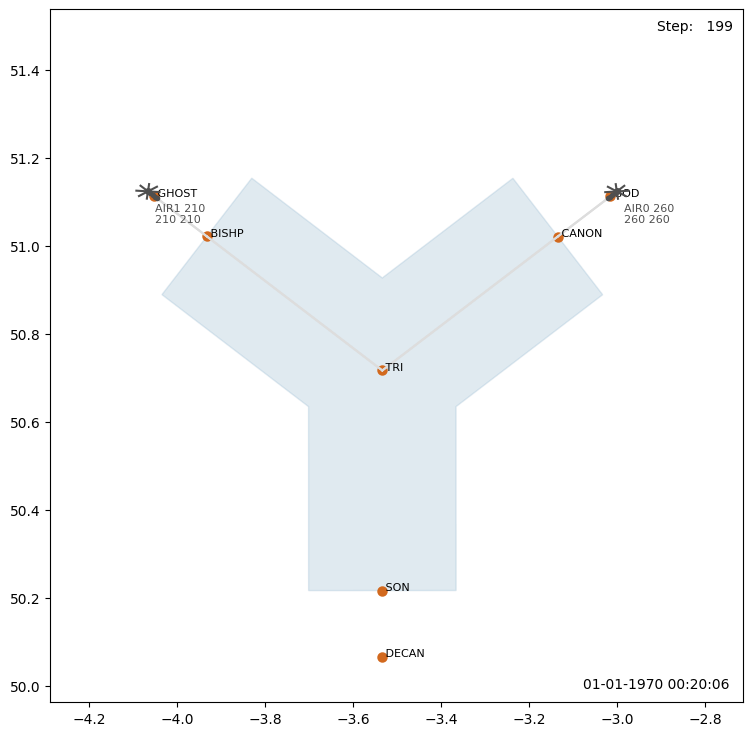

In [10]:
import IPython.display

# the radar is re-instantiated. no need to clear the screen.
radar = Radar(view_centre, view_width, aspect_ratio) # re-introduce the spines/axes

for _ in range(200):
    sim.evolve(6.0)
    figure, ax = radar.draw(sim.manager.environment)

    IPython.display.display(figure) # or IPython.display.display(plt.gcf())
    IPython.display.clear_output(wait=True)

### How do I see what scenarios are available?

So far we have looked at two "Artificial" scenarios, but how do we know what is available to us, to write as the "category" and "scenario_name" arguments of `Simulator.from_category(category, scenario_name)`?  The easiest way is for us to use the following functions: 

In [13]:
from bluebird_dt.simulator.common import list_sim_scenario_categories, list_sim_scenarios
# list the categories
list_sim_scenario_categories()

['Artificial', 'Springfield', 'Infinite']

In [14]:
# pick one of these and list the scenarios within it
list_sim_scenarios("Springfield")

['example-scenario', 'llm-scenario', 'testScenario']

### Loading a Springfield scenario

The "Springfield" airspace is more complex than the very simple Artificial airspaces we have seen so far - it has a more complex geometry, and a set of possible "airways" that are designed to test how agents (or humans) could deal with tricky problems in real life Air Traffic Control.

In [19]:
sim = Simulator.from_category("Springfield", "example-scenario")

In order to show the Springfield airspace, we will need to modify the settings for the Radar class

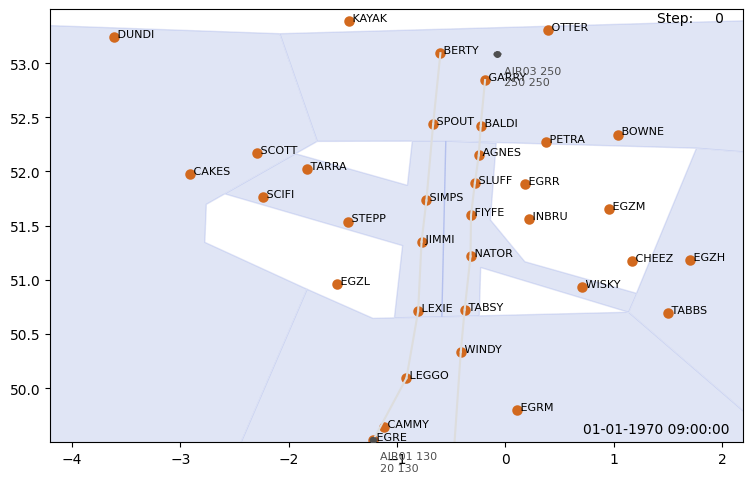

In [26]:
view_centre = Pos2D.from_str("51.5N 1W")
view_width = 240.0  # [nmi] about 1 degree of longitude
aspect_ratio = 1.6
radar = Radar(view_centre, view_width, aspect_ratio)
radar.draw(sim.manager.environment)
plt.show()

### Accessing the environment programatically

You probably noticed that when we did the visualisation in the cell above, the object we passed to Radar's `draw` method was `sim.manager.environment`.   This is an instance of the bluebird_dt `Environment` class, and it holds essentially all the data that we (or an AI agent) might need, at a particular snapshot of time.

For example, we can get the current positions of all the aircraft:

In [28]:
for aircraft in sim.manager.environment.aircraft.values():
    print(f"{aircraft.callsign}: latlon = ({aircraft.lat},{aircraft.lon}), Flight Level = {aircraft.fl}")

AIR01: latlon = (49.5230110183851,-1.21774853983122), Flight Level = 20.0
AIR03: latlon = (53.0821052255996,-0.072430948633466), Flight Level = 250.0


If we evolve the simulation a few steps, we can see how these positions change.

In [29]:
for _ in range(10):
    sim.evolve(6)

for aircraft in sim.manager.environment.aircraft.values():
    print(f"{aircraft.callsign}: latlon = ({aircraft.lat},{aircraft.lon}), Flight Level = {aircraft.fl}")

AIR01: latlon = (49.67915642787576,-1.138333898163054), Flight Level = 40.000000000000014
AIR03: latlon = (52.975459018413716,-0.12137608775694521), Flight Level = 250.0


So we can see that both aircraft moved in this time.

### How do I know what data is available for Environment, Aircraft, etc.?

There are a couple of options:
* You can look at the code itself - the classes that represent "things" such as Aircraft are in the `bluebird_dt/core/` directory.
* You can look at the auto-generated source code reference in the web-based documentation.
* You can use the python `help` or `inspect` functionality to investigate the class you are interested in

In [30]:
from bluebird_dt.core import Aircraft
help(Aircraft)

Help on class Aircraft in module bluebird_dt.core.aircraft:

class Aircraft(bluebird_dt.mixin.core_mixin.Comparison)
 |  Aircraft(
 |      lat: 'float',
 |      lon: 'float',
 |      fl: 'float',
 |      heading: 'float',
 |      flight_plan: 'FlightPlan | None',
 |      callsign: 'str',
 |      selected_fl: 'int | None' = None,
 |      ufid: 'str | None' = None,
 |      rate_of_turn: 'float | None' = None,
 |      aircraft_type: 'str | None' = None,
 |      operation_params: 'dict | None' = None,
 |      controllable: 'bool' = True,
 |      simulated: 'bool' = True,
 |      current_sector: 'str | None' = None,
 |      random_seed: 'int | None' = None,
 |      pilot: 'Pilot | None' = None,
 |      squawk: 'str | None' = None,
 |      wake_vortex: 'str | None' = None,
 |      last_passed_filed_idx: 'int | None' = None,
 |      last_passed_current_idx: 'int | None' = None,
 |      squawk_ident_until: 'float | None' = None
 |  )
 |
 |  An aeroplane, helicopter, or other machine capable of


In this notebook, we have taken a small peek under the hood of the digital twin, as well as finding out how to know what scenarios are available.  

In the next notebook, Part 3, we will look at yet another scenario type, and how to customize it to meet our needs.